<h1>PART A</h1>

# Homework: Comparing BERT Fine-Tuning Scenarios

## Objective

This homework aims to provide a practical understanding of different approaches to fine-tuning BERT for a text classification task. You will explore three scenarios:
1.  **Full Fine-Tuning**: Fine-tuning all layers of a pre-trained BERT model.
2.  **LoRA Fine-Tuning**: Using Low-Rank Adaptation (LoRA) for parameter-efficient fine-tuning.
3.  **Few-Shot Learning**: Adapting BERT for a scenario with limited training data, typically by freezing the base model and training a small classification head.

You will compare the performance of these methods on a dataset of book descriptions and their genres (titles).

## Setup

Before you begin, ensure you have the necessary libraries installed and the dataset ready.

### 1. Install Libraries

Run the first cell to install `torchao` and other dependencies. You might also need `transformers` and `peft`.

### 2. Load and Preprocess Data

**TODO**: Ensure your `preprocessed.json` dataset is loaded and ready for use.

```python
# TODO: Add code to load your dataset if it's not already handled in the notebook.
# Example: Load your JSON data from a specific path
# with open("/path/to/your/dataset.json", "r", encoding="utf-8") as f:
#     data = json.load(f)
```

## Notebook Structure

This notebook is divided into several sections:

### 1. Dataset Classes (`TitleLabelEncoder`, `GoodreadsDataset`)

-   `TitleLabelEncoder`: A utility class to convert categorical labels (book titles/genres) into numerical IDs and vice-versa. This is essential for training classification models.
-   `GoodreadsDataset`: A PyTorch `Dataset` class that prepares your text and labels for input into a BERT model. It handles tokenization using a pre-trained BERT tokenizer.

### 2. Base Model (`BaseClassifier`)

An abstract base class for our classification models. All concrete model implementations will inherit from this, ensuring a consistent interface.

### 3. Full Fine-Tuning (`FullFineTuneBERT`)

This section defines a model that takes a pre-trained `bert-base-uncased` model and adds a linear classification head on top. During training, all parameters of the BERT model are updated along with the classification head.

### 4. LoRA Fine-Tuning (`LoRABERTClassifier`)

This class implements LoRA (Low-Rank Adaptation) for fine-tuning. Instead of updating all BERT parameters, LoRA injects small, trainable rank-decomposition matrices into existing layers. This significantly reduces the number of trainable parameters while often achieving comparable performance.

### 5. Few-Shot Learning (`FewShotCLSClassifier`)

This scenario is designed for situations with very limited training data. Here, the pre-trained BERT model's parameters are frozen, and only a small, custom classification head (a simple neural network) is trained on top of BERT's `[CLS]` token embedding.

### 6. Trainer (`Trainer`)

This class encapsulates the training and evaluation logic. It includes methods for:

-   `train_epoch`: Performs one epoch of training, including forward pass, loss calculation, backward pass, and optimizer step.
-   `evaluate_epoch`: Evaluates the model on a validation set, calculating the loss without updating weights.
-   `evaluate_accuracy`: Calculates the classification accuracy on a given DataLoader.

### 7. Configuration & Data Preparation

This section sets up global configurations (like random seed, number of epochs, learning rates for each scenario) and prepares the dataset.

-   **SEED**: For reproducibility.
-   **SCENARIOS_TO_RUN**: A list of scenarios to execute.
-   **EPOCHS & LEARNING_RATES**: Hyperparameters for training.
-   **Data Preparation**: This involves extracting texts and labels, encoding labels using `TitleLabelEncoder`, tokenizing with `BertTokenizer`, creating a `GoodreadsDataset`, and splitting it into training and validation sets using `random_split`.
-   **DataLoader**: Creates `DataLoader` objects for efficient batching during training and evaluation.

### 8. Scenario Runner Function (`run_scenario`)

A helper function to orchestrate the training and evaluation for a single scenario. It selects the appropriate model, sets up the optimizer and loss function, and runs the training loop.

### 9. Run All Scenarios and Compare

This is the main execution block where each defined scenario is run using the `run_scenario` function. It collects the final validation accuracy for each scenario and prints a comparison.

### 10. Small Data Scenarios

This section duplicates the configuration and data preparation, but specifically for a smaller subset of the original data. This is crucial for observing how the different fine-tuning approaches behave under data scarcity.

Good luck!

In [1]:
!pip install torchao==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [2]:
import json
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import BertModel, BertTokenizer
from peft import LoraConfig, get_peft_model
from tqdm import tqdm
import pandas as pd
import random
import numpy as np
from torch.optim import AdamW

In [4]:
# !unzip /content/MIR-Project-SP2026-main.zip
import json
with open("preprocessed.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# 1. Dataset Class

In [5]:
class TitleLabelEncoder:

    def __init__(self):
        self.title_to_id = {}
        self.id_to_title = {}

    def fit(self, titles):
        unique_titles = sorted(set(titles))  # TODO completed
        self.title_to_id = {title: idx for idx, title in enumerate(unique_titles)}  # TODO completed
        self.id_to_title = {idx: title for idx, title in enumerate(unique_titles)}  # TODO completed

    def encode(self, title):
        return self.title_to_id[title]

    def decode(self, idx):
        return self.id_to_title[idx]

    def transform(self, titles):
        return [self.encode(t) for t in titles]  # TODO completed

    def inverse_transform(self, indices):
        return [self.decode(i) for i in indices]  # TODO completed

    @property
    def num_classes(self):
        return len(self.title_to_id)


In [6]:
class GoodreadsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(  # TODO completed
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {  # TODO completed
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(label, dtype=torch.long),
        }


# 2. Base Model

In [7]:
from abc import ABC, abstractmethod
import torch.nn as nn

class BaseClassifier(nn.Module, ABC):

    @abstractmethod
    def forward(self, input_ids, attention_mask):
        pass

# 3. First Scenario: Full Fine-Tuning

In [8]:
class FullFineTuneBERT(BaseClassifier):

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)  # TODO completed

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        logits = self.classifier(outputs.pooler_output)  # TODO completed
        return logits


# 4. Second Scenarion: LoRA Fine-Tuning

In [9]:
class LoRABERTClassifier(BaseClassifier):

    def __init__(self, num_classes):
        super().__init__()
        model = BertModel.from_pretrained("bert-base-uncased")
        lora_config = LoraConfig(
            r=8, lora_alpha=16,
            target_modules=["query", "value"],
            lora_dropout=0.1, bias="none",
        )
        self.bert       = get_peft_model(model, lora_config)              # TODO completed
        self.classifier = nn.Linear(model.config.hidden_size, num_classes)  # TODO completed

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        logits = self.classifier(outputs.pooler_output)  # TODO completed
        return logits


# 4. Third Scenarion: Few-Shot Learning

In [10]:
class FewShotCLSClassifier(BaseClassifier):

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Freeze BERT
        for param in self.bert.parameters():
            param.requires_grad = False  # TODO completed

        self.classifier = nn.Sequential(  # TODO completed
            nn.Linear(self.bert.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(outputs.pooler_output)  # TODO completed
        return logits


# 5. Trainer

In [11]:
class Trainer:

    def __init__(self, model, optimizer, criterion, device):
        self.model     = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device    = device

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0
        for batch in tqdm(dataloader):
            input_ids      = batch["input_ids"].to(self.device)       # TODO completed
            attention_mask = batch["attention_mask"].to(self.device)   # TODO completed
            labels         = batch["label"].to(self.device)            # TODO completed
            self.optimizer.zero_grad()
            logits = self.model(input_ids, attention_mask)  # TODO completed
            loss   = self.criterion(logits, labels)         # TODO completed
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(dataloader)  # TODO completed

    def evaluate_epoch(self, dataloader):
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch in tqdm(dataloader):
                input_ids      = batch["input_ids"].to(self.device)       # TODO completed
                attention_mask = batch["attention_mask"].to(self.device)   # TODO completed
                labels         = batch["label"].to(self.device)            # TODO completed
                logits = self.model(input_ids, attention_mask)  # TODO completed
                loss   = self.criterion(logits, labels)         # TODO completed
                total_loss += loss.item()
        return total_loss / len(dataloader)  # TODO completed

    def evaluate_accuracy(self, dataloader):
        self.model.eval()
        correct_predictions = 0
        total_predictions   = 0
        with torch.no_grad():
            for batch in tqdm(dataloader):
                input_ids      = batch["input_ids"].to(self.device)       # TODO completed
                attention_mask = batch["attention_mask"].to(self.device)   # TODO completed
                labels         = batch["label"].to(self.device)            # TODO completed
                logits      = self.model(input_ids, attention_mask)  # TODO completed
                predictions = torch.argmax(logits, dim=1)            # TODO completed
                correct_predictions += (predictions == labels).sum().item()
                total_predictions   += labels.size(0)
        return correct_predictions / total_predictions  # TODO completed


# 6. Configuration & Data

In [12]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SCENARIOS_TO_RUN = ["full", "lora", "fewshot"]
EPOCHS = 10
LEARNING_RATES = {
    "full":    2e-5,   # TODO completed
    "lora":    3e-4,   # TODO completed
    "fewshot": 1e-3,   # TODO completed
}

# Count title frequencies
title_counts = {}
for item in data:
    title = item['title']
    title_counts[title] = title_counts.get(title, 0) + 1  # TODO completed

sorted_titles_by_freq  = sorted(title_counts, key=title_counts.get, reverse=True)  # TODO completed
top_10_frequent_titles = sorted_titles_by_freq[:10]  # TODO completed

filtered_data = [item for item in data if item['title'] in set(top_10_frequent_titles)]  # TODO completed

texts  = [item['description'] for item in filtered_data]  # TODO completed
titles = [item['title']       for item in filtered_data]  # TODO completed

label_encoder  = TitleLabelEncoder()
label_encoder.fit(titles)
encoded_labels = label_encoder.transform(titles)
tokenizer      = BertTokenizer.from_pretrained("bert-base-uncased")

dataset = GoodreadsDataset(texts=texts, labels=encoded_labels, tokenizer=tokenizer)

train_size = int(0.8 * len(dataset))     # TODO completed
val_size   = len(dataset) - train_size   # TODO completed
train_dataset, val_dataset = random_split(  # TODO completed
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)   # TODO completed
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)  # TODO completed

NUM_CLASSES = label_encoder.num_classes
print("Number of classes:", NUM_CLASSES)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Number of classes: 10
Training samples: 113, Validation samples: 29


In [13]:
import os

def run_scenario(scenario_name, num_classes, train_loader, val_loader,
                 learning_rate, epochs, device, save_weights=False):
    print(f"\n--- Running Scenario: {scenario_name} ---")

    if scenario_name.startswith("full"):
        model = FullFineTuneBERT(num_classes)
    elif scenario_name.startswith("lora"):
        model = LoRABERTClassifier(num_classes)
    elif scenario_name.startswith("fewshot"):
        model = FewShotCLSClassifier(num_classes)
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    trainer   = Trainer(model, optimizer, criterion, device=device)

    for epoch in range(epochs):
        train_loss = trainer.train_epoch(train_loader)    # TODO completed
        val_loss   = trainer.evaluate_epoch(val_loader)   # TODO completed
        print(f"Epoch {epoch+1}/{epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    if save_weights:
        save_path = f"{scenario_name}_bert_weights.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Model weights for '{scenario_name}' saved to {save_path}")

    final_val_accuracy = trainer.evaluate_accuracy(val_loader)  # TODO completed
    print(f"Final Validation Accuracy for {scenario_name}: {final_val_accuracy:.4f}")
    return final_val_accuracy


In [14]:
results = {}
device  = "cuda" if torch.cuda.is_available() else "cpu"

for scenario in SCENARIOS_TO_RUN:
    acc = run_scenario(
        scenario, NUM_CLASSES, train_loader, val_loader,
        LEARNING_RATES[scenario], EPOCHS, device, save_weights=True,
    )
    results[scenario] = acc

print("\n--- Scenario Comparison ---")
for scenario, accuracy in results.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario = max(results, key=results.get)  # TODO completed
print(f"\nBest performing scenario: {best_scenario} with accuracy {results[best_scenario]:.4f}")



--- Running Scenario: full ---


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 2/2 [00:00<00:00,  5.45it/s]


...

Epoch 9/10: Train Loss = 2.3213, Val Loss = 2.2977


100%|██████████| 2/2 [00:00<00:00,  4.49it/s]


Epoch 10/10: Train Loss = 2.2341, Val Loss = 2.4864
Model weights for 'fewshot' saved to fewshot_bert_weights.pth


100%|██████████| 2/2 [00:00<00:00,  3.97it/s]

Final Validation Accuracy for fewshot: 0.0345

--- Scenario Comparison ---
full: 0.9655
lora: 0.3103
fewshot: 0.0345

Best performing scenario: full with accuracy 0.9655


In [15]:
SCENARIOS_TO_RUN_SMALL = ["full", "lora", "fewshot"]
EPOCHS = 10
LEARNING_RATES = {
    "full":    2e-5,   # TODO completed
    "lora":    3e-4,   # TODO completed
    "fewshot": 1e-3,   # TODO completed
}

small_data = len(dataset) // 3
remaining_dataset_length = len(dataset) - small_data
small_dataset_for_split, _ = random_split(
    dataset, [small_data, remaining_dataset_length],
    generator=torch.Generator().manual_seed(SEED),
)

train_size_small = int(0.8 * small_data)          # TODO completed
val_size_small   = small_data - train_size_small   # TODO completed
train_dataset_small, val_dataset_small = random_split(
    small_dataset_for_split, [train_size_small, val_size_small],
    generator=torch.Generator().manual_seed(SEED),
)

print("\n--- Data Split for small data scenarios ---")
print(f"Small Data Training samples: {len(train_dataset_small)}, Validation samples: {len(val_dataset_small)}")

train_loader_small = DataLoader(train_dataset_small, batch_size=16, shuffle=True)   # TODO completed
val_loader_small   = DataLoader(val_dataset_small,   batch_size=16, shuffle=False)  # TODO completed



--- Data Split for small data scenarios ---
Small Data Training samples: 37, Validation samples: 10


In [16]:
results_small_data = {}

for scenario in SCENARIOS_TO_RUN_SMALL:
    acc = run_scenario(
        scenario, NUM_CLASSES, train_loader_small, val_loader_small,
        LEARNING_RATES[scenario], EPOCHS, device,
    )
    results_small_data[scenario] = acc

print("\n--- Scenario Comparison ---")
for scenario, accuracy in results_small_data.items():
    print(f"{scenario}: {accuracy:.4f}")

best_scenario_small = max(results_small_data, key=results_small_data.get)  # TODO completed
print(f"\nBest performing scenario: {best_scenario_small} with accuracy {results_small_data[best_scenario_small]:.4f}")



--- Running Scenario: full ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1/1 [00:00<00:00,  6.84it/s]


Epoch 1/10: Train Loss = 2.3506, Val Loss = 2.2489


100%|██████████| 1/1 [00:00<00:00,  7.03it/s]


...

Epoch 9/10: Train Loss = 2.1247, Val Loss = 2.1509


100%|██████████| 1/1 [00:00<00:00,  6.45it/s]


Epoch 10/10: Train Loss = 2.0556, Val Loss = 2.1899


100%|██████████| 1/1 [00:00<00:00,  6.28it/s]

Final Validation Accuracy for fewshot: 0.1000

--- Scenario Comparison ---
full: 0.5000
lora: 0.4000
fewshot: 0.1000

Best performing scenario: full with accuracy 0.5000


<h1>PART B</h1>

<div style="font-size: 20px; line-height: 1.7;">

In this part, we analyze how BERT representations change across layers before and after fine-tuning.

We compare two models:

1. **Pretrained BERT**: the original BERT model without task-specific training.
2. **Full Fine-Tuned BERT**: the BERT model after being trained on the book title classification task.

For each model, we extract the hidden representation of the `[CLS]` token from every BERT layer. The `[CLS]` vector is used because it represents the whole input description and is also used by the classifier for prediction.

Then, we apply **PCA** to project these high-dimensional vectors into 2D space and visualize them. Each point represents one book description, and colors correspond to the true book title class.

Finally, we compute the **Silhouette Score** for each layer to measure how well the class representations are separated. A higher score means that samples from the same class are closer together and samples from different classes are farther apart.

The goal is to see whether fine-tuning makes the upper BERT layers more task-specific and better separated for the classification task.

</div>

In [17]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

<h2>Main Configuration</h2>

In [20]:
# =========================================
# Main visualization configuration
# =========================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to the saved full fine-tuned BERT weights.
# This should match the file saved during your training stage.
FULL_FINETUNED_CKPT = "full_bert_weights.pth"

# Directory where all plots and CSV files will be saved.
OUTPUT_DIR = "layerwise_bert_visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Use only part of the validation set for faster visualization.
# Set this to None if you want to use the entire validation set.
MAX_BATCHES = 20

# Pooling method:
# "cls"  = use the [CLS] token representation.
# "mean" = average all valid token representations.
POOLING = "cls"

# Selected layers for detailed plots.
# Layer 0 is the embedding output.
# Layers 1 to 12 are Transformer encoder layers.
SELECTED_LAYERS = [0, 1, 4, 8, 12]

print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("Pooling method:", POOLING)

Device: cuda
Output directory: layerwise_bert_visualizations
Pooling method: cls


<h2>Build Pretrained and Fine-Tuned Models</h2>

In [21]:
def build_pretrained_model(num_classes, device):
    model = FullFineTuneBERT(num_classes)
    model.to(device)
    model.eval()
    return model

def build_finetuned_model(num_classes, checkpoint_path, device):
    model      = FullFineTuneBERT(num_classes)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    return model

pretrained_model = build_pretrained_model(NUM_CLASSES, DEVICE)                   # TODO completed
finetuned_model  = build_finetuned_model(NUM_CLASSES, FULL_FINETUNED_CKPT, DEVICE)  # TODO completed

print("Pretrained BERT model is ready.")
print("Full fine-tuned BERT model is ready.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pretrained BERT model is ready.
Full fine-tuned BERT model is ready.


<h2>Pooling Functions</h2>

In [22]:
def mean_pooling(hidden_state, attention_mask):
    mask                = attention_mask.unsqueeze(-1).float()          # TODO completed
    masked_hidden_state = hidden_state * mask                           # TODO completed
    summed_hidden_state = masked_hidden_state.sum(dim=1)                # TODO completed
    valid_token_count   = mask.sum(dim=1).clamp(min=1e-9)               # TODO completed
    pooled_output       = summed_hidden_state / valid_token_count       # TODO completed
    return pooled_output

def pool_hidden_state(hidden_state, attention_mask, pooling="cls"):
    if pooling == "cls":
        return hidden_state[:, 0, :]                    # TODO completed
    if pooling == "mean":
        return mean_pooling(hidden_state, attention_mask)  # TODO completed
    raise ValueError("pooling must be either 'cls' or 'mean'")


<h2>Extract Layer-Wise Representations</h2>

In [23]:
def extract_layer_representations(model, dataloader, device, pooling="cls", max_batches=None):
    model.eval()
    layer_vectors = None
    all_labels    = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader)):
            if max_batches is not None and batch_idx >= max_batches:
                break

            input_ids      = batch["input_ids"].to(device)       # TODO completed
            attention_mask = batch["attention_mask"].to(device)   # TODO completed
            labels         = batch["label"]                       # TODO completed

            outputs = model.bert(  # TODO completed
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )

            hidden_states = outputs.hidden_states

            if layer_vectors is None:
                layer_vectors = {layer_idx: [] for layer_idx in range(len(hidden_states))}

            for layer_idx, hidden_state in enumerate(hidden_states):
                pooled_vectors = pool_hidden_state(hidden_state, attention_mask, pooling=pooling)  # TODO completed
                layer_vectors[layer_idx].append(pooled_vectors.detach().cpu().numpy())

            all_labels.append(labels)

    for layer_idx in layer_vectors:
        layer_vectors[layer_idx] = np.concatenate(layer_vectors[layer_idx], axis=0)  # TODO completed

    all_labels = np.concatenate([l.numpy() for l in all_labels], axis=0)  # TODO completed

    return layer_vectors, all_labels


<h2>Extract Representations for Both Models</h2>

In [24]:
# =========================================
# Extract representations from pretrained and fine-tuned models
# =========================================

pretrained_layer_vectors, y_labels = extract_layer_representations(
    model=pretrained_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

finetuned_layer_vectors, y_labels_finetuned = extract_layer_representations(
    model=finetuned_model,
    dataloader=val_loader,
    device=DEVICE,
    pooling=POOLING,
    max_batches=MAX_BATCHES
)

assert np.array_equal(y_labels, y_labels_finetuned)

print("Representation extraction finished.")
print("Number of samples:", len(y_labels))
print("Number of layers:", len(pretrained_layer_vectors))
print("Shape of layer 12 vectors:", pretrained_layer_vectors[12].shape)

100%|██████████| 2/2 [00:00<00:00,  4.69it/s]

Representation extraction finished.
Number of samples: 29
Number of layers: 13
Shape of layer 12 vectors: (29, 768)


<h2>Helper Function for Short Class Names</h2>

In [25]:
def shorten_text(text, max_length=35):
    text = str(text)
    if len(text) <= max_length:
        return text
    return text[:max_length - 3] + "..."

def get_class_name(class_id, label_encoder):
    """Return the human-readable class name for a numeric class id."""
    class_name = label_encoder.decode(class_id)  # TODO completed
    return class_name                             # TODO completed

class_names = [get_class_name(i, label_encoder) for i in range(label_encoder.num_classes)]
print("Class names:", class_names)


Class names: ['a tale of two citi', 'anna karenina', 'one hundr year of solitud', 'pride and prejudic', 'siddhartha', 'the brother karamazov', 'the hous of mirth', 'the lord of the ring', 'the pictur of dorian gray', 'the silmarillion']


<h2>PCA Visualization for One Model and One Layer</h2>

In [26]:
def visualize_single_layer_pca(vectors, labels, label_encoder, title,
                                output_file=None, show_plot=True):
    pca             = PCA(n_components=2)                # TODO completed
    reduced_vectors = pca.fit_transform(vectors)         # TODO completed

    plt.figure(figsize=(10, 8))
    unique_labels = sorted(np.unique(labels))
    for label_id in unique_labels:
        mask = labels == label_id
        plt.scatter(reduced_vectors[mask, 0], reduced_vectors[mask, 1],
                    label=shorten_text(get_class_name(label_id, label_encoder)),
                    alpha=0.6, s=20)
    plt.title(title)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    plt.legend(loc="best", fontsize=7, markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches="tight")
        print("Saved:", output_file)
    if show_plot:
        plt.show()
    else:
        plt.close()


<h2>Visualize Selected Layers Separately</h2>

Saved: layerwise_bert_visualizations/pretrained_layer_0_cls_pca.png


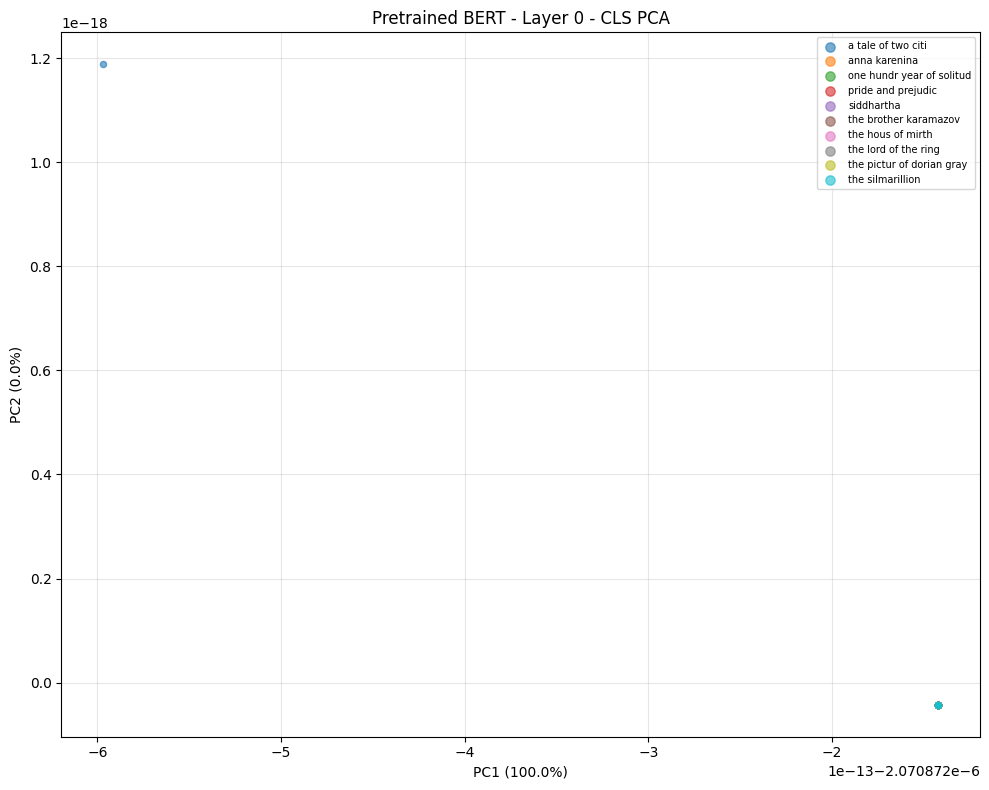

Saved: layerwise_bert_visualizations/finetuned_layer_0_cls_pca.png


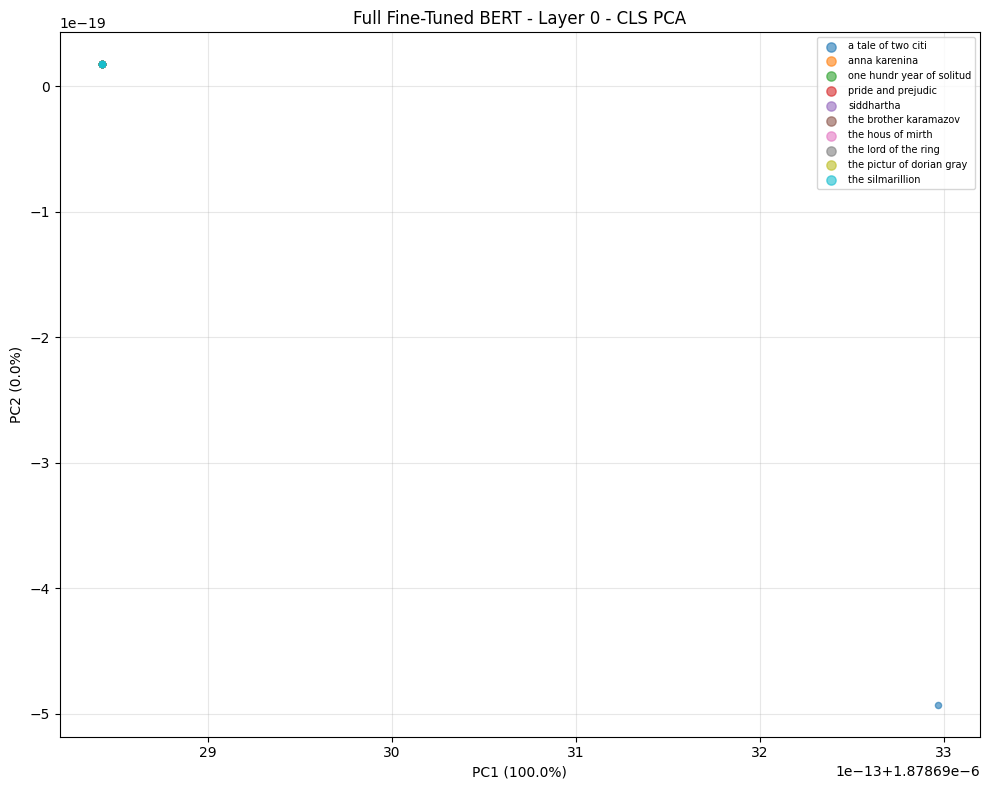

Saved: layerwise_bert_visualizations/pretrained_layer_1_cls_pca.png


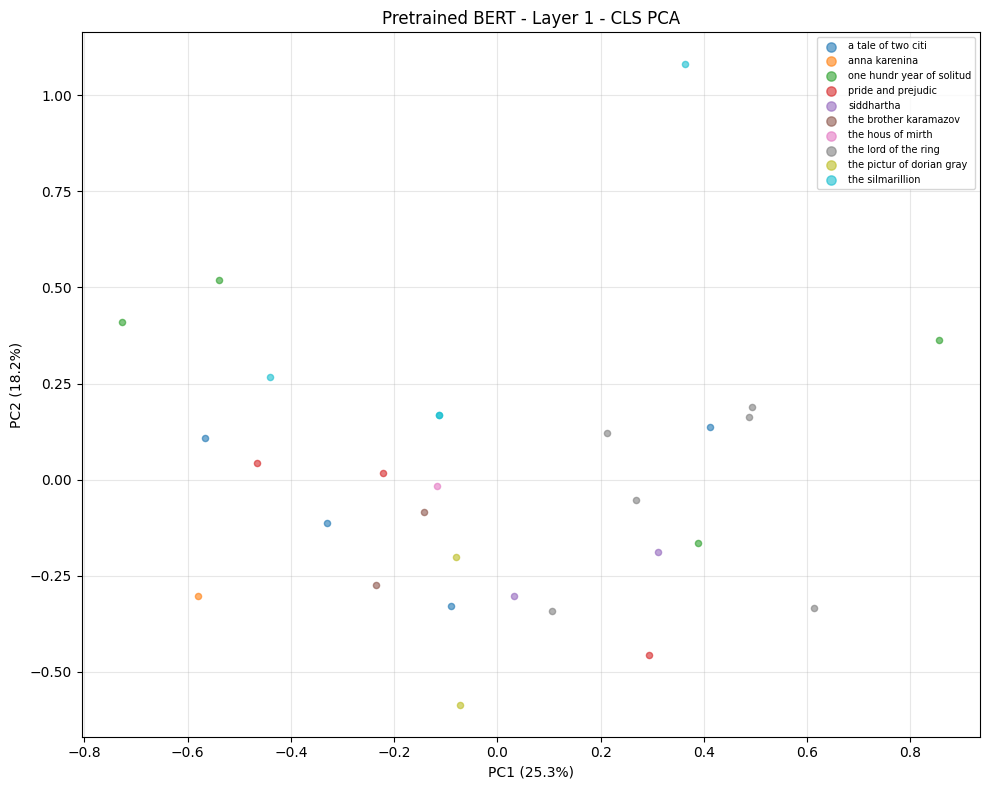

Saved: layerwise_bert_visualizations/finetuned_layer_1_cls_pca.png


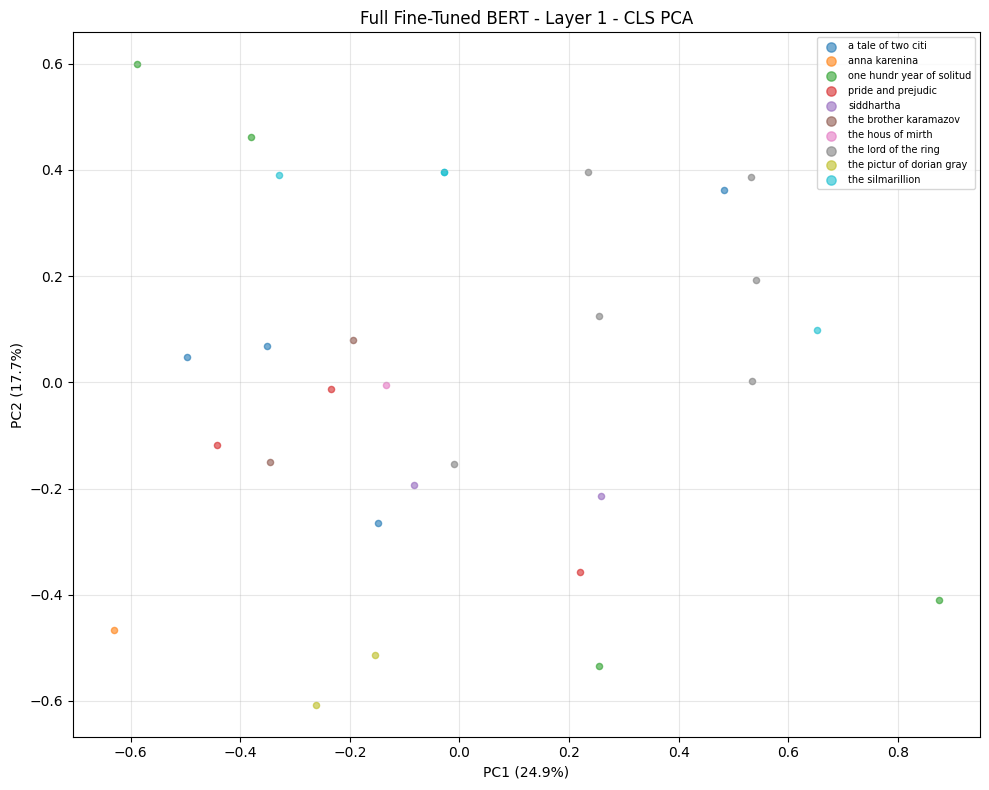

Saved: layerwise_bert_visualizations/pretrained_layer_4_cls_pca.png


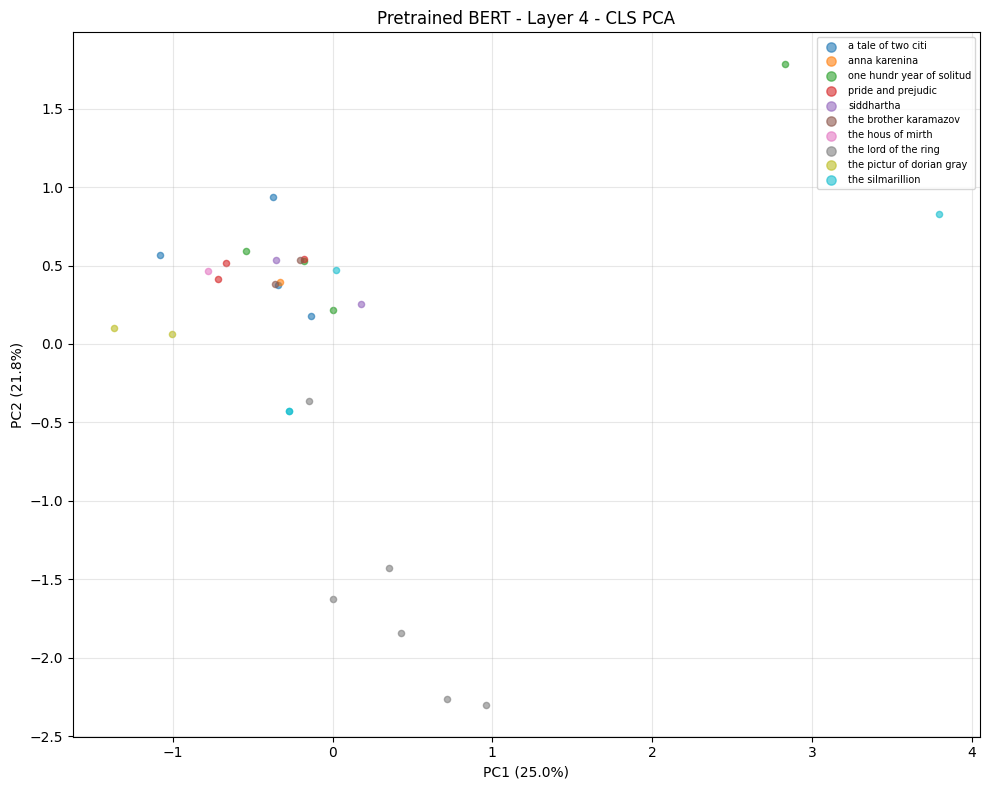

Saved: layerwise_bert_visualizations/finetuned_layer_4_cls_pca.png


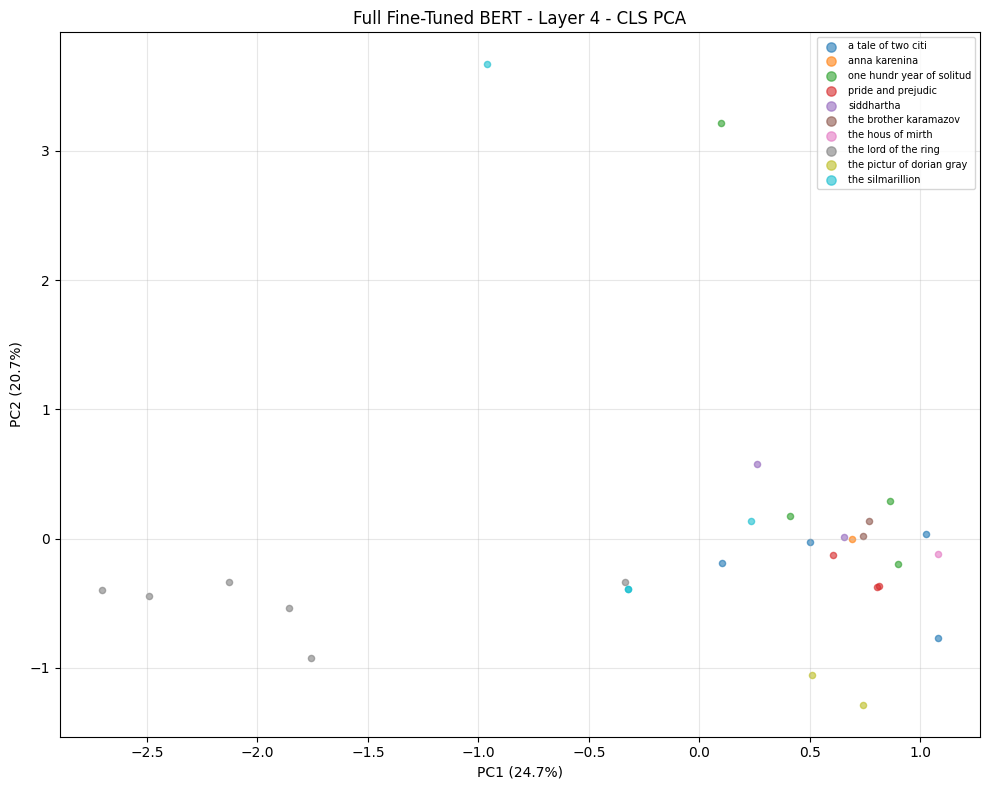

Saved: layerwise_bert_visualizations/pretrained_layer_8_cls_pca.png


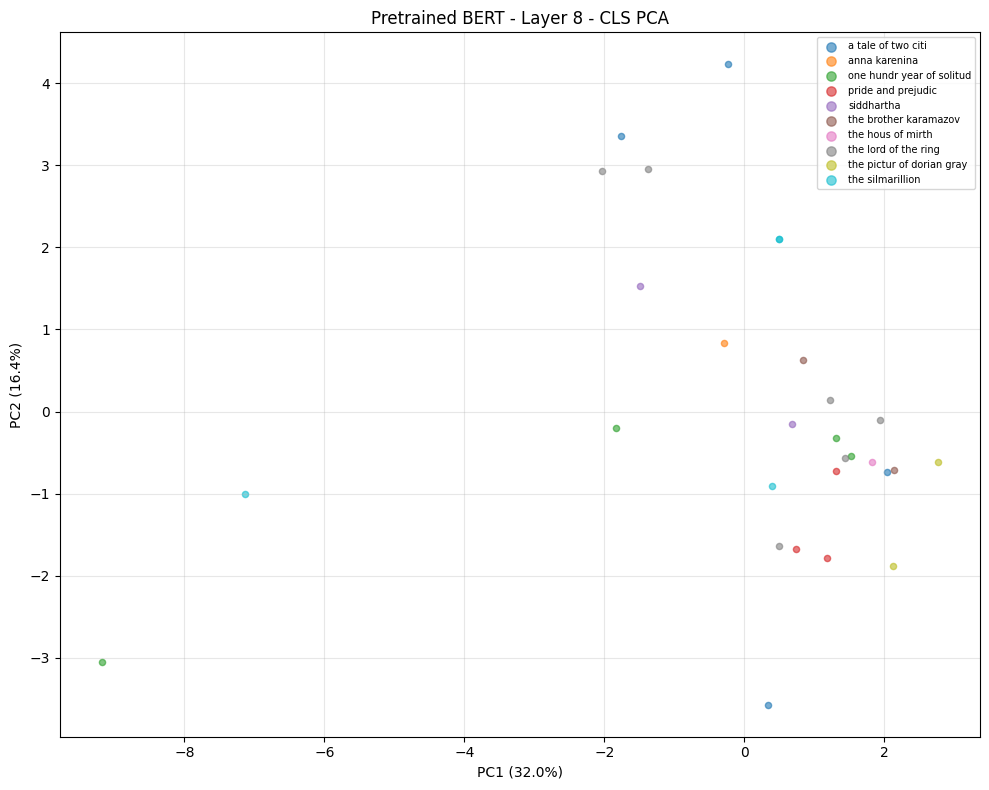

Saved: layerwise_bert_visualizations/finetuned_layer_8_cls_pca.png


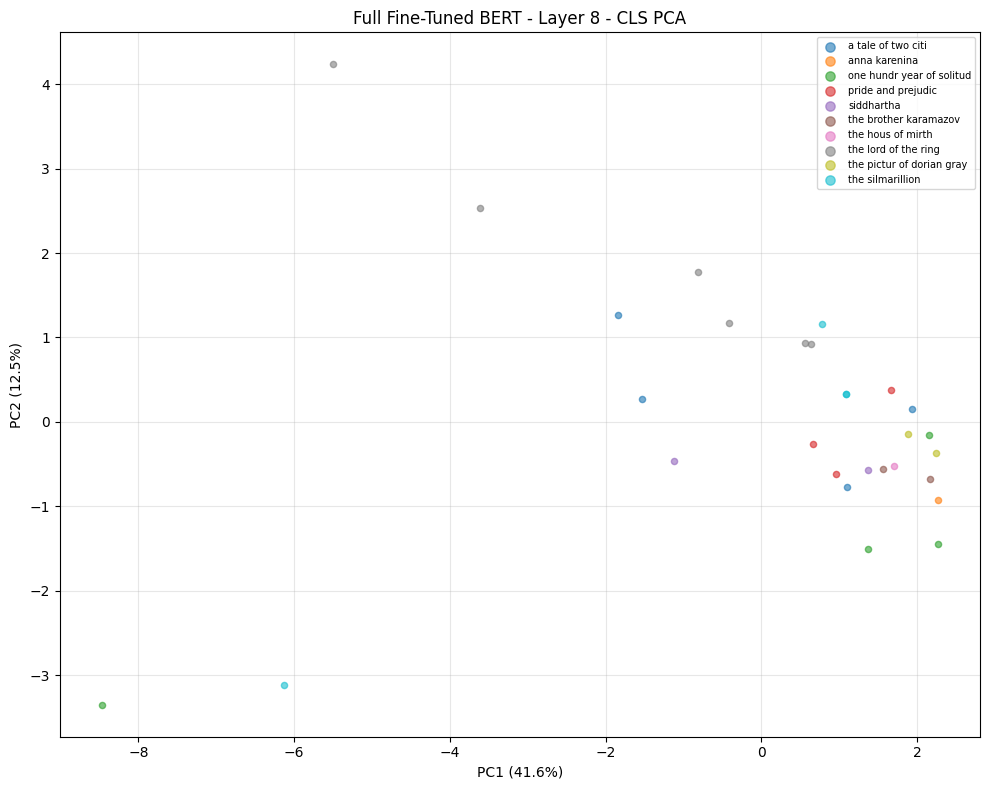

Saved: layerwise_bert_visualizations/pretrained_layer_12_cls_pca.png


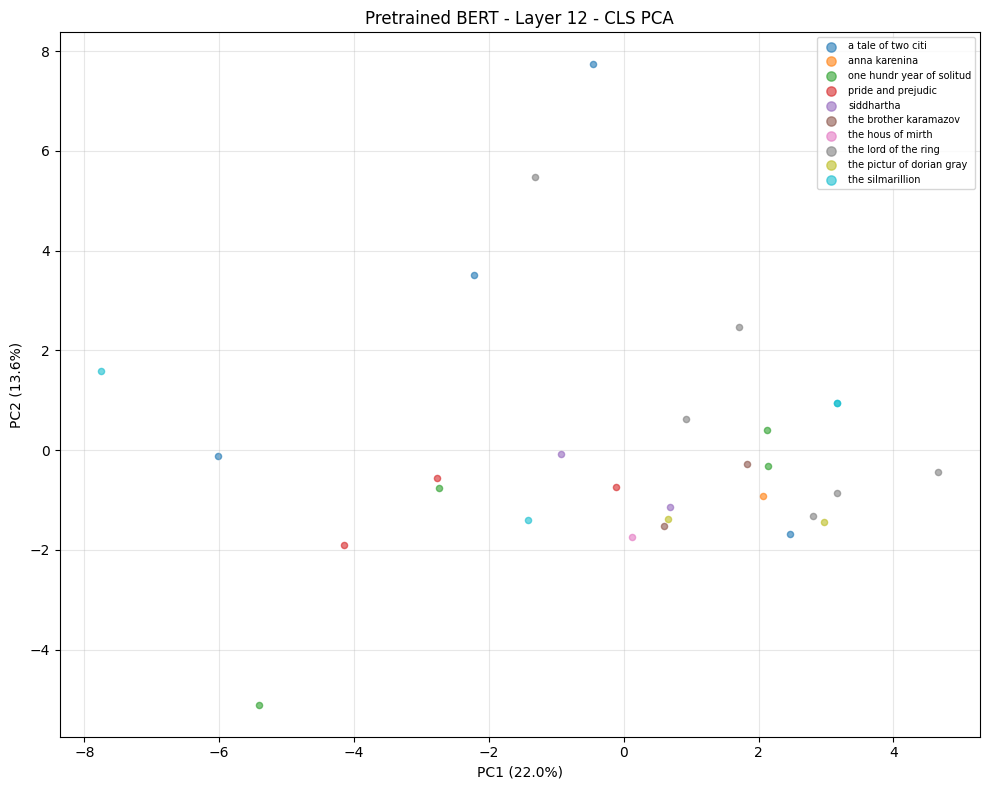

Saved: layerwise_bert_visualizations/finetuned_layer_12_cls_pca.png


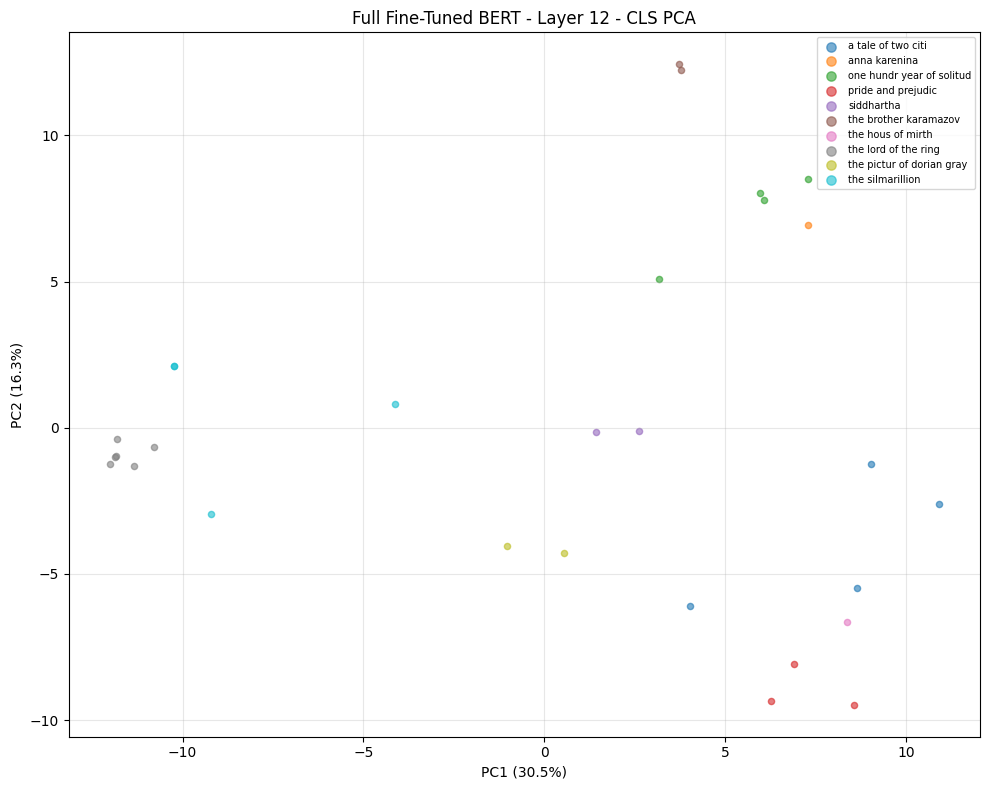

In [27]:
# =========================================
# Visualize selected layers separately
# =========================================

for layer_idx in SELECTED_LAYERS:

    pretrained_output_file = os.path.join(
        OUTPUT_DIR,
        f"pretrained_layer_{layer_idx}_{POOLING}_pca.png"
    )

    finetuned_output_file = os.path.join(
        OUTPUT_DIR,
        f"finetuned_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_single_layer_pca(
        vectors=pretrained_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Pretrained BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=pretrained_output_file
    )

    visualize_single_layer_pca(
        vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        title=f"Full Fine-Tuned BERT - Layer {layer_idx} - {POOLING.upper()} PCA",
        output_file=finetuned_output_file
    )

<h2>Side-by-Side Comparison for One Layer</h2>

In [28]:
def visualize_layer_comparison_pca(pretrained_vectors, finetuned_vectors, labels,
                                    label_encoder, layer_idx,
                                    output_file=None, show_plot=True):
    combined_vectors = np.concatenate([pretrained_vectors, finetuned_vectors], axis=0)  # TODO completed
    pca              = PCA(n_components=2)                                               # TODO completed
    combined_reduced = pca.fit_transform(combined_vectors)                               # TODO completed

    num_samples        = len(pretrained_vectors)                # TODO completed
    pretrained_reduced = combined_reduced[:num_samples]         # TODO completed
    finetuned_reduced  = combined_reduced[num_samples:]         # TODO completed
    unique_labels      = sorted(np.unique(labels))              # TODO completed

    plt.figure(figsize=(18, 7))

    for subplot_idx, (reduced, title_str) in enumerate([
        (pretrained_reduced, f"Pretrained BERT — Layer {layer_idx}"),
        (finetuned_reduced,  f"Full Fine-Tuned BERT — Layer {layer_idx}"),
    ]):
        plt.subplot(1, 2, subplot_idx + 1)
        for label_id in unique_labels:
            mask = labels == label_id
            plt.scatter(reduced[mask, 0], reduced[mask, 1],
                        label=shorten_text(get_class_name(label_id, label_encoder)),
                        alpha=0.6, s=20)
        plt.title(title_str)
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
        plt.legend(loc="best", fontsize=7, markerscale=1.5)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches="tight")
        print("Saved:", output_file)
    if show_plot:
        plt.show()
    else:
        plt.close()


<h2>Run Side-by-Side Comparison for Selected Layers</h2>

Saved: layerwise_bert_visualizations/comparison_layer_0_cls_pca.png


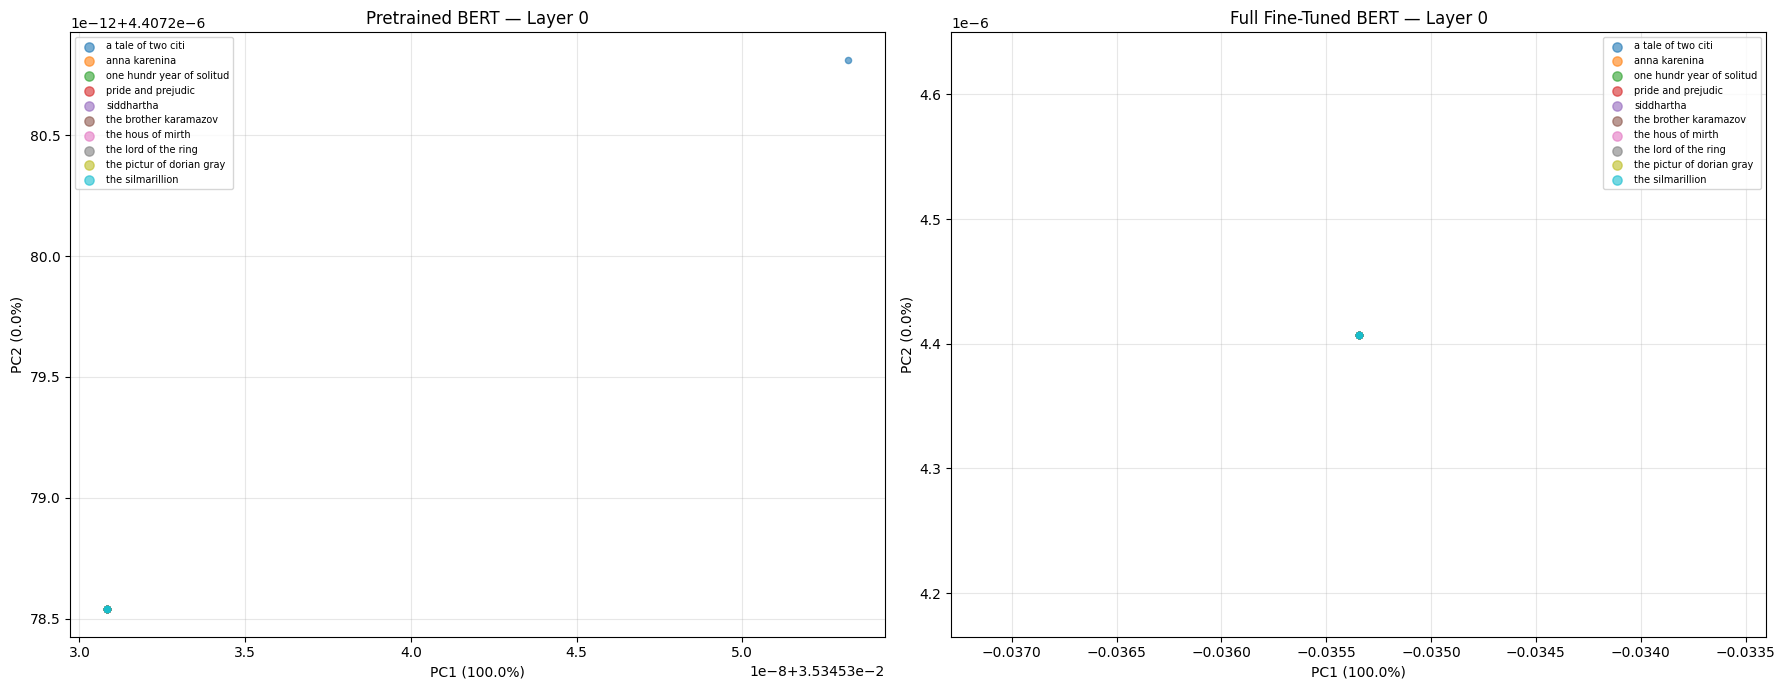

Saved: layerwise_bert_visualizations/comparison_layer_1_cls_pca.png


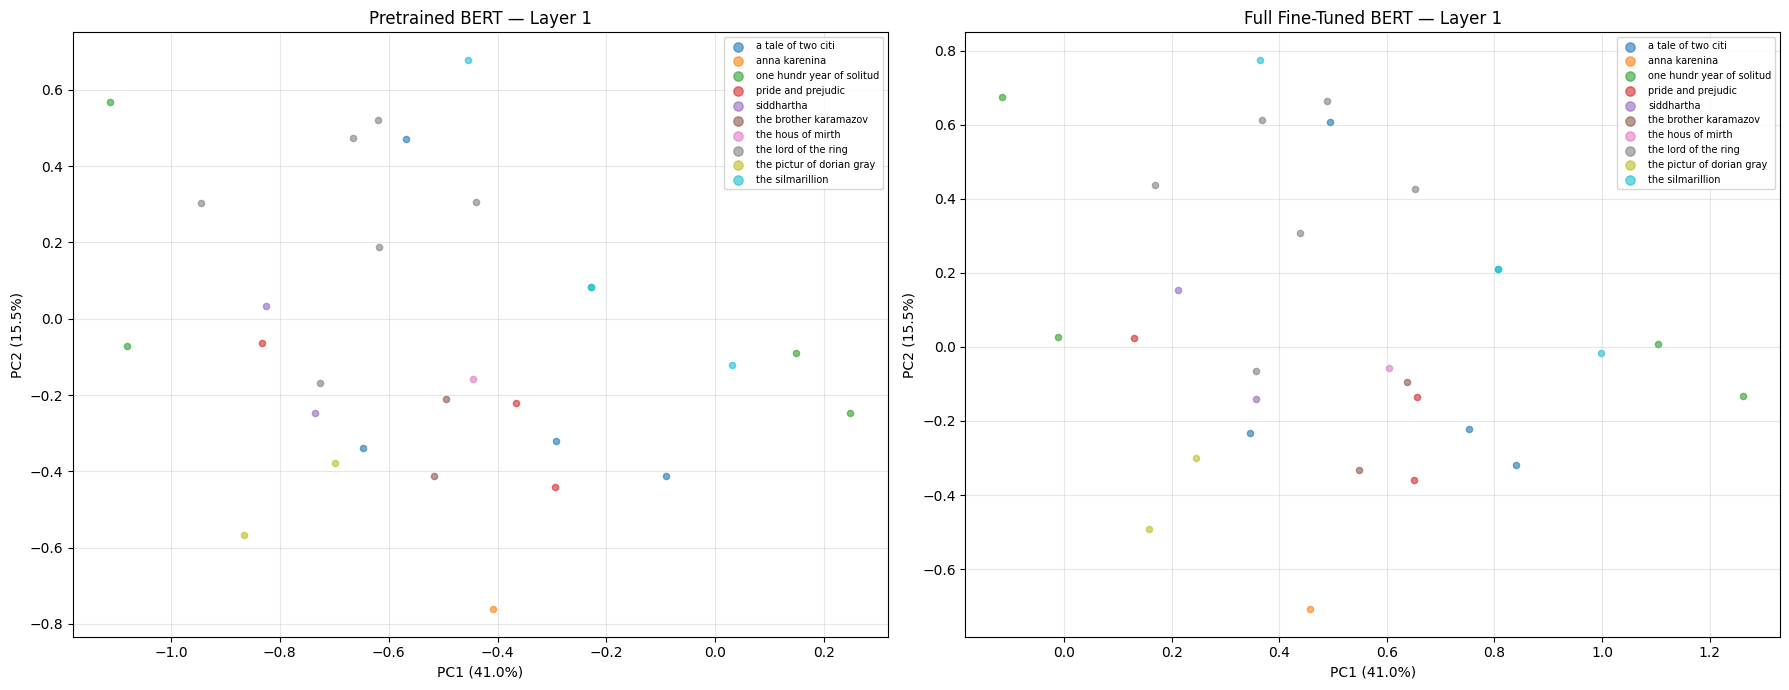

Saved: layerwise_bert_visualizations/comparison_layer_4_cls_pca.png


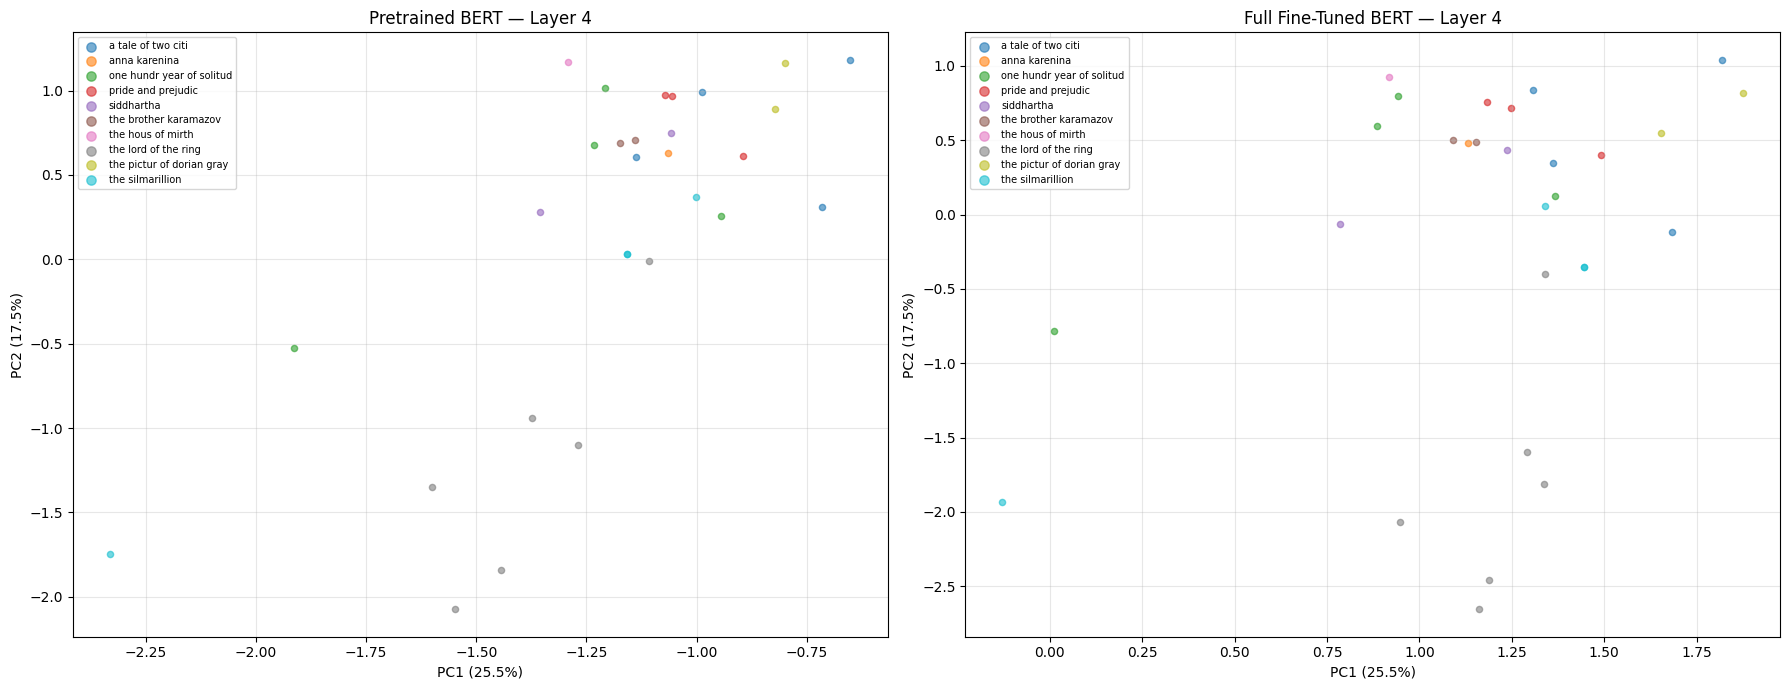

Saved: layerwise_bert_visualizations/comparison_layer_8_cls_pca.png


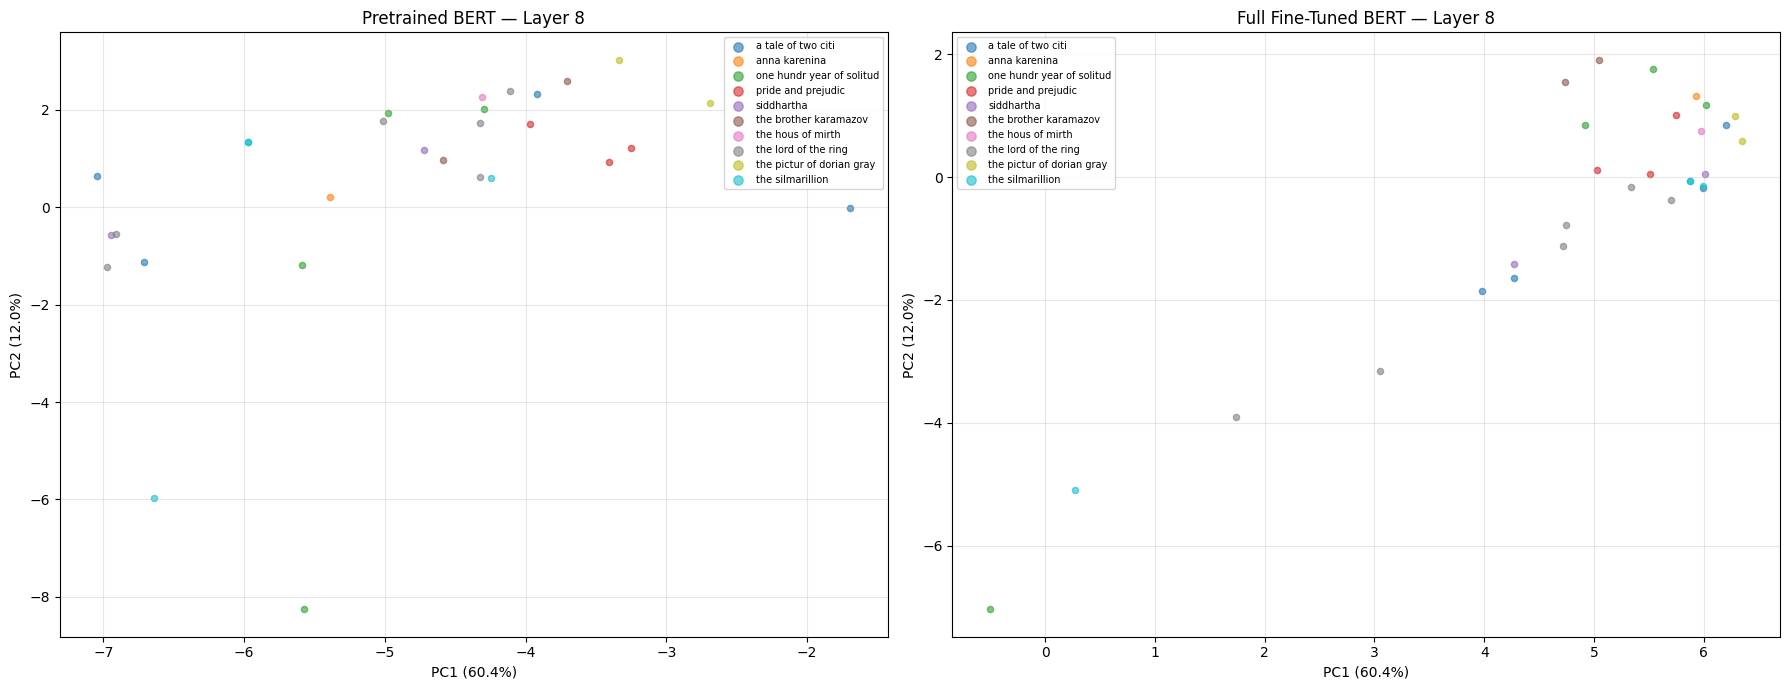

Saved: layerwise_bert_visualizations/comparison_layer_12_cls_pca.png


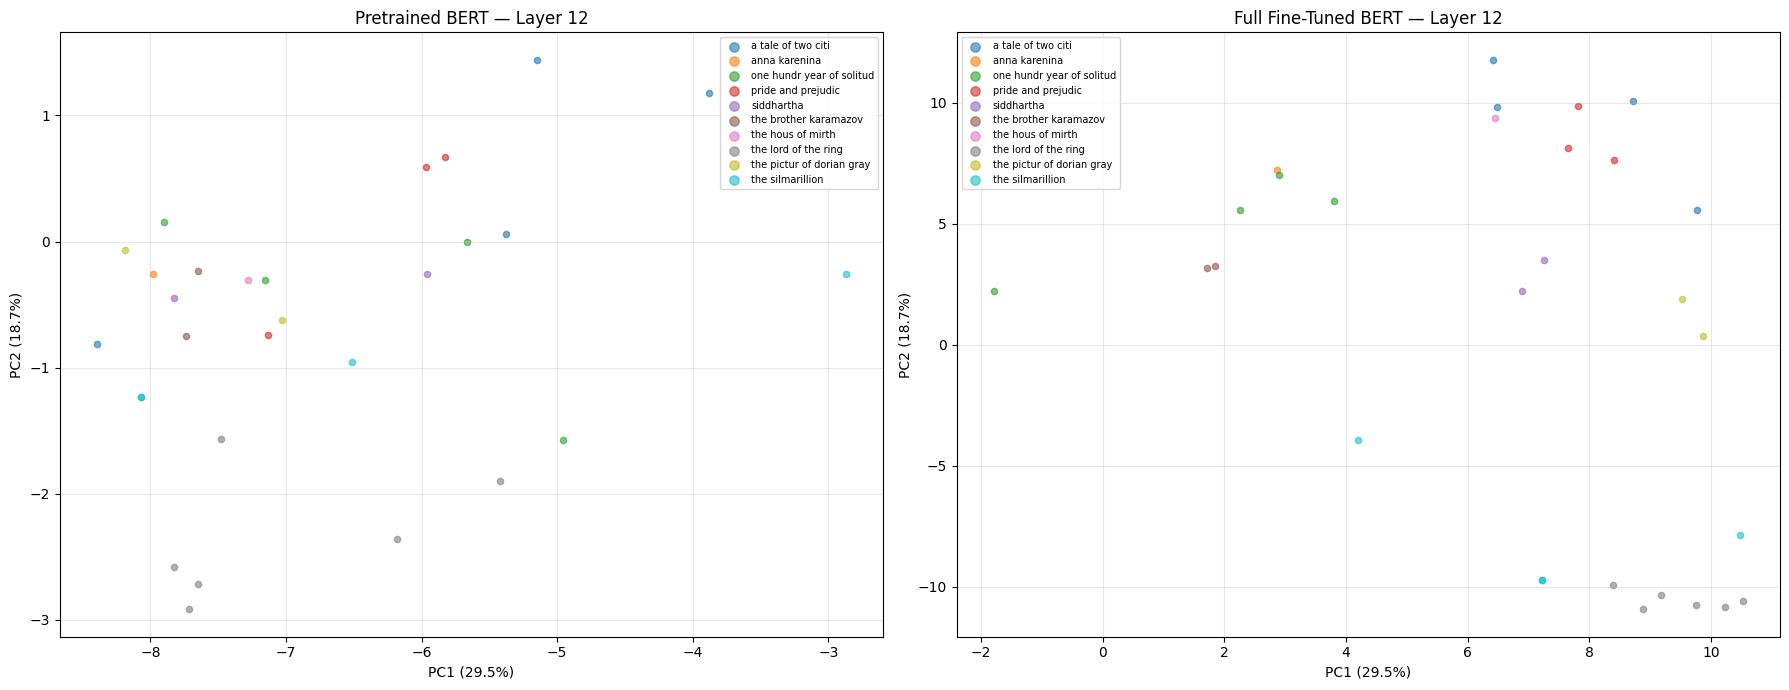

In [29]:
# =========================================
# Run side-by-side PCA comparison for selected layers
# =========================================

for layer_idx in SELECTED_LAYERS:

    output_file = os.path.join(
        OUTPUT_DIR,
        f"comparison_layer_{layer_idx}_{POOLING}_pca.png"
    )

    visualize_layer_comparison_pca(
        pretrained_vectors=pretrained_layer_vectors[layer_idx],
        finetuned_vectors=finetuned_layer_vectors[layer_idx],
        labels=y_labels,
        label_encoder=label_encoder,
        layer_idx=layer_idx,
        output_file=output_file
    )

<h2>Grid Visualization Across All Layers</h2>

In [30]:
def visualize_all_layers_grid(layer_vectors, labels, model_name,
                               output_file=None, show_plot=True):
    num_layers = len(layer_vectors)   # TODO completed
    num_cols   = 4
    num_rows   = int(np.ceil(num_layers / num_cols))
    unique_labels = sorted(np.unique(labels))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = np.array(axes).ravel()

    for layer_idx in range(num_layers):
        vectors         = layer_vectors[layer_idx]   # TODO completed
        pca             = PCA(n_components=2)         # TODO completed
        reduced_vectors = pca.fit_transform(vectors)
        ax = axes[layer_idx]
        for label_id in unique_labels:
            mask = labels == label_id
            ax.scatter(reduced_vectors[mask, 0], reduced_vectors[mask, 1],
                       alpha=0.5, s=8, linewidths=0)
        ax.set_title(f"Layer {layer_idx}", fontsize=9)
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", fontsize=7)
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.2)

    for idx in range(num_layers, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f"{model_name} — Layer-wise PCA", fontsize=14, y=1.01)
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches="tight")
        print("Saved:", output_file)
    if show_plot:
        plt.show()
    else:
        plt.close()


<h2>Save Grid Plots for Both Models</h2>

In [31]:
def plot_all_layers_grid(layer_vectors, labels, model_name,
                          output_file=None, show_plot=True):
    """Plot PCA projections of all BERT layers in a grid."""
    num_layers    = len(layer_vectors)              # TODO completed
    num_cols      = 4
    num_rows      = int(np.ceil(num_layers / num_cols))
    unique_labels = sorted(np.unique(labels))       # TODO completed

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = np.array(axes).ravel()

    for layer_idx in range(num_layers):
        vectors         = layer_vectors[layer_idx]  # TODO completed
        pca             = PCA(n_components=2)        # TODO completed
        reduced_vectors = pca.fit_transform(vectors)

        ax = axes[layer_idx]
        for label_id in unique_labels:
            mask = labels == label_id
            ax.scatter(reduced_vectors[mask, 0], reduced_vectors[mask, 1],
                       alpha=0.5, s=8, linewidths=0)
        ax.set_title(f"Layer {layer_idx}", fontsize=9)
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", fontsize=7)
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.2)

    for idx in range(num_layers, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f"{model_name} — All Layers PCA Grid", fontsize=14, y=1.01)
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)
    if show_plot:
        plt.show()
    else:
        plt.close()


<h2>Plot Pretrained BERT Grid</h2>

Saved: layerwise_bert_visualizations/pretrained_all_layers_cls_grid.png


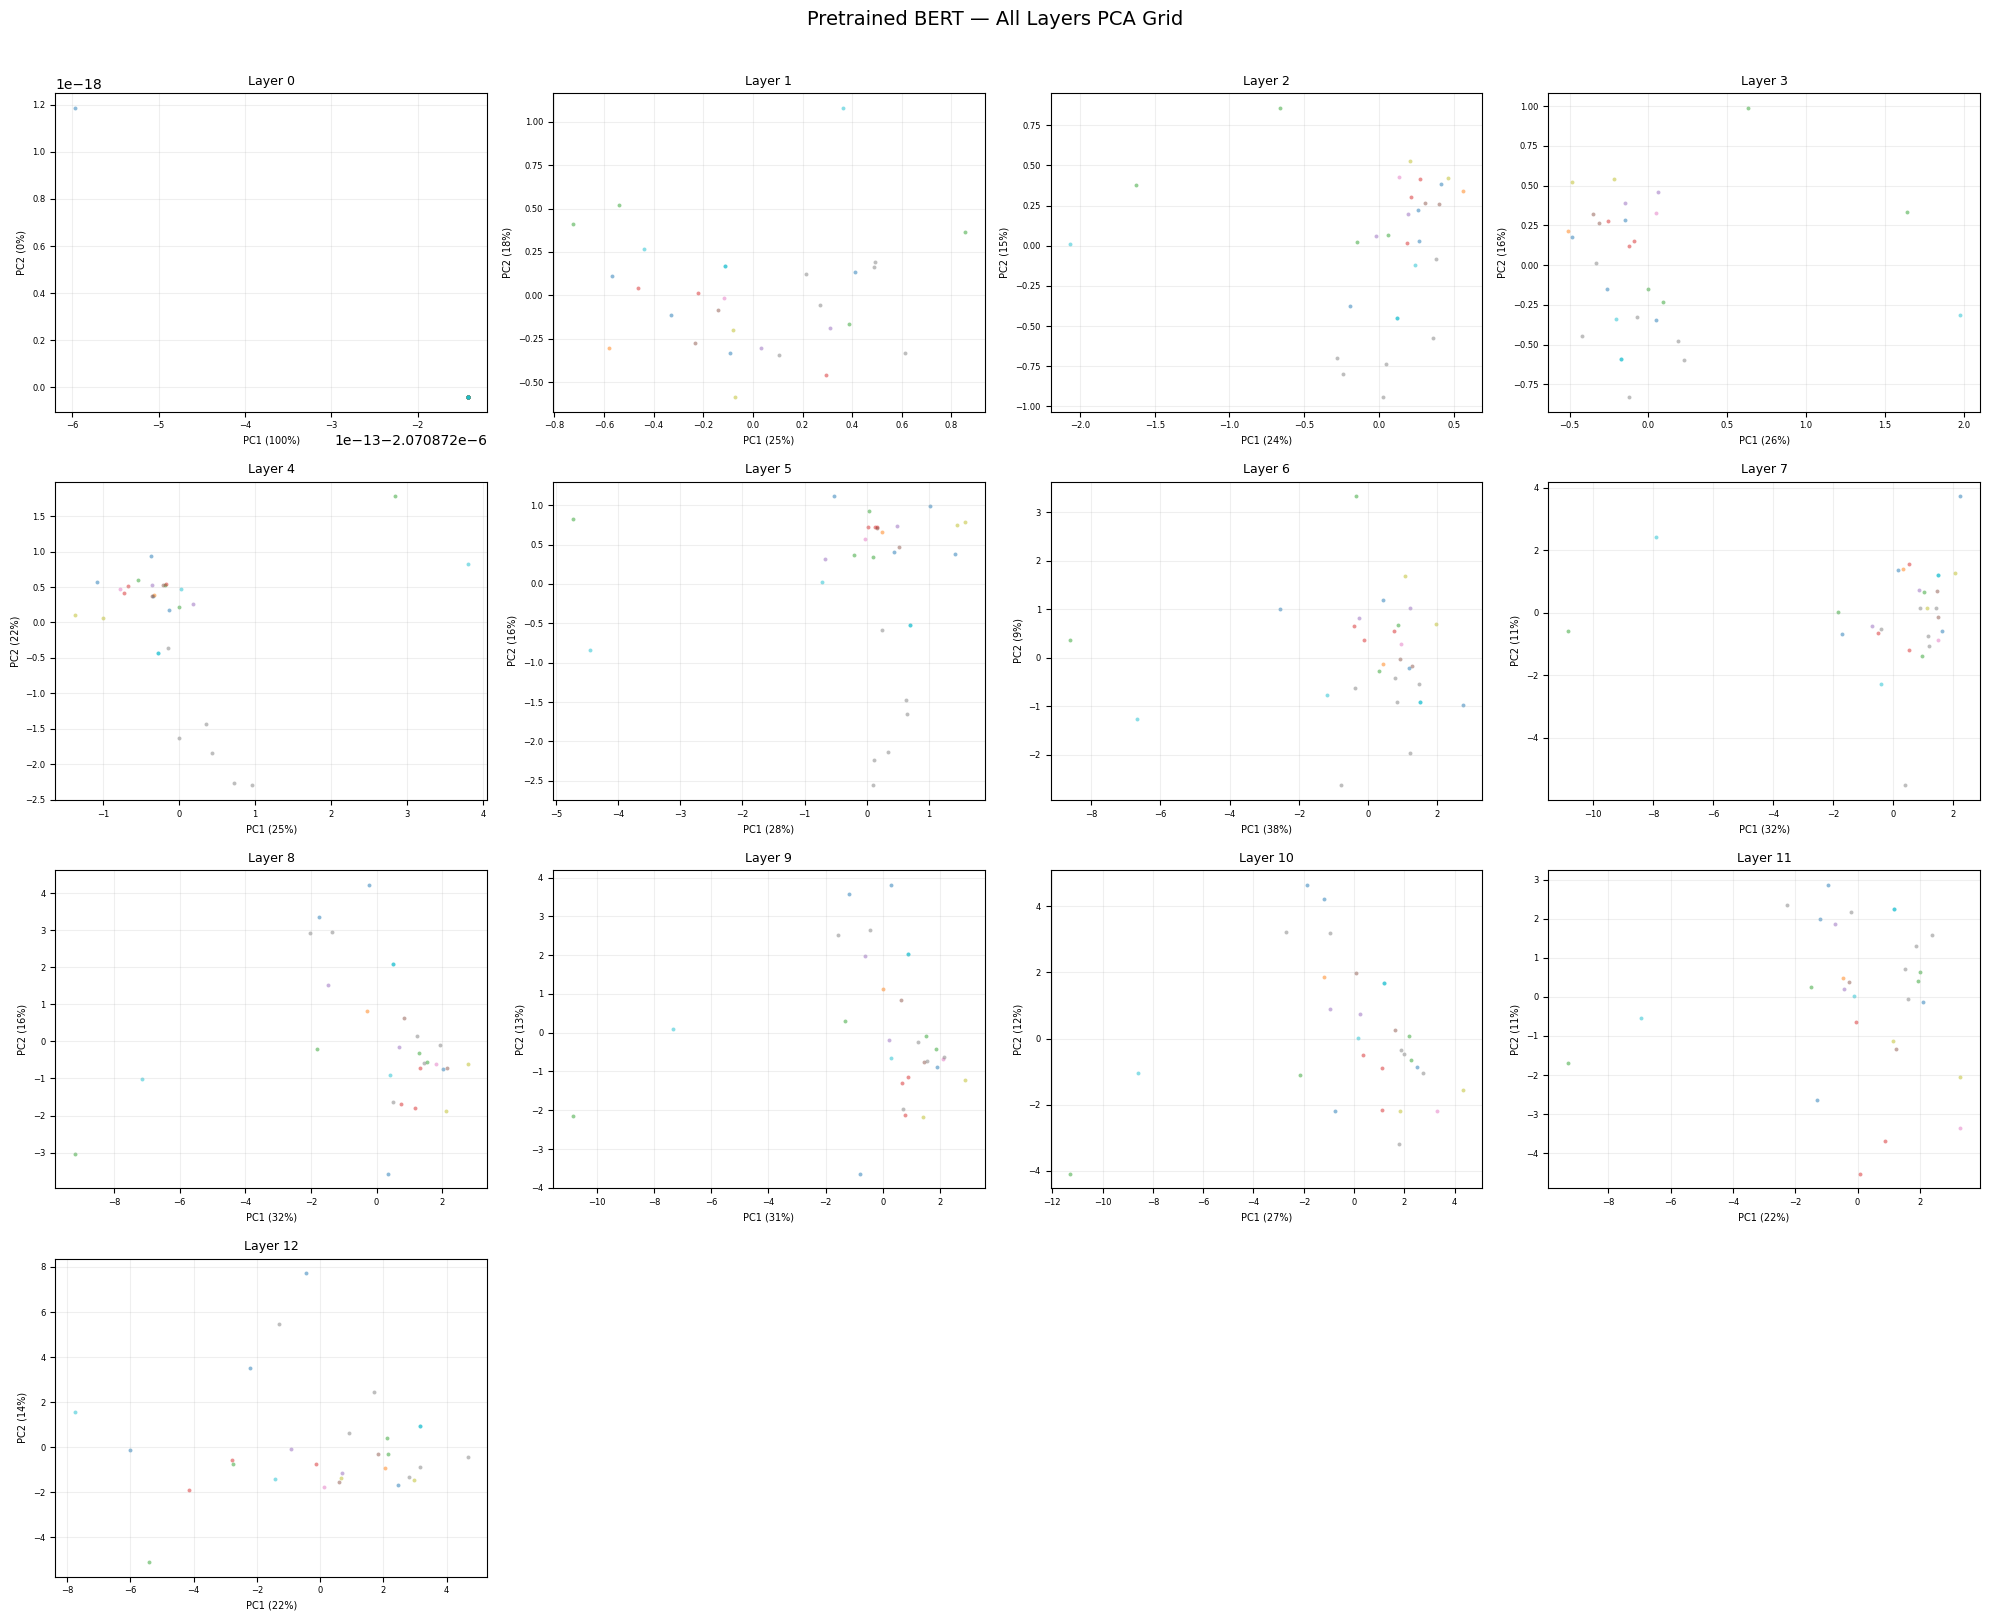

In [32]:
# =========================================
# Plot pretrained BERT layer-wise PCA grid
# =========================================

pretrained_grid_file = os.path.join(
    OUTPUT_DIR,
    f"pretrained_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=pretrained_layer_vectors,
    labels=y_labels,
    model_name="Pretrained BERT",
    output_file=pretrained_grid_file,
    show_plot=True
)

<h2>Plot Full Fine-Tuned BERT Grid</h2>

Saved: layerwise_bert_visualizations/finetuned_all_layers_cls_grid.png


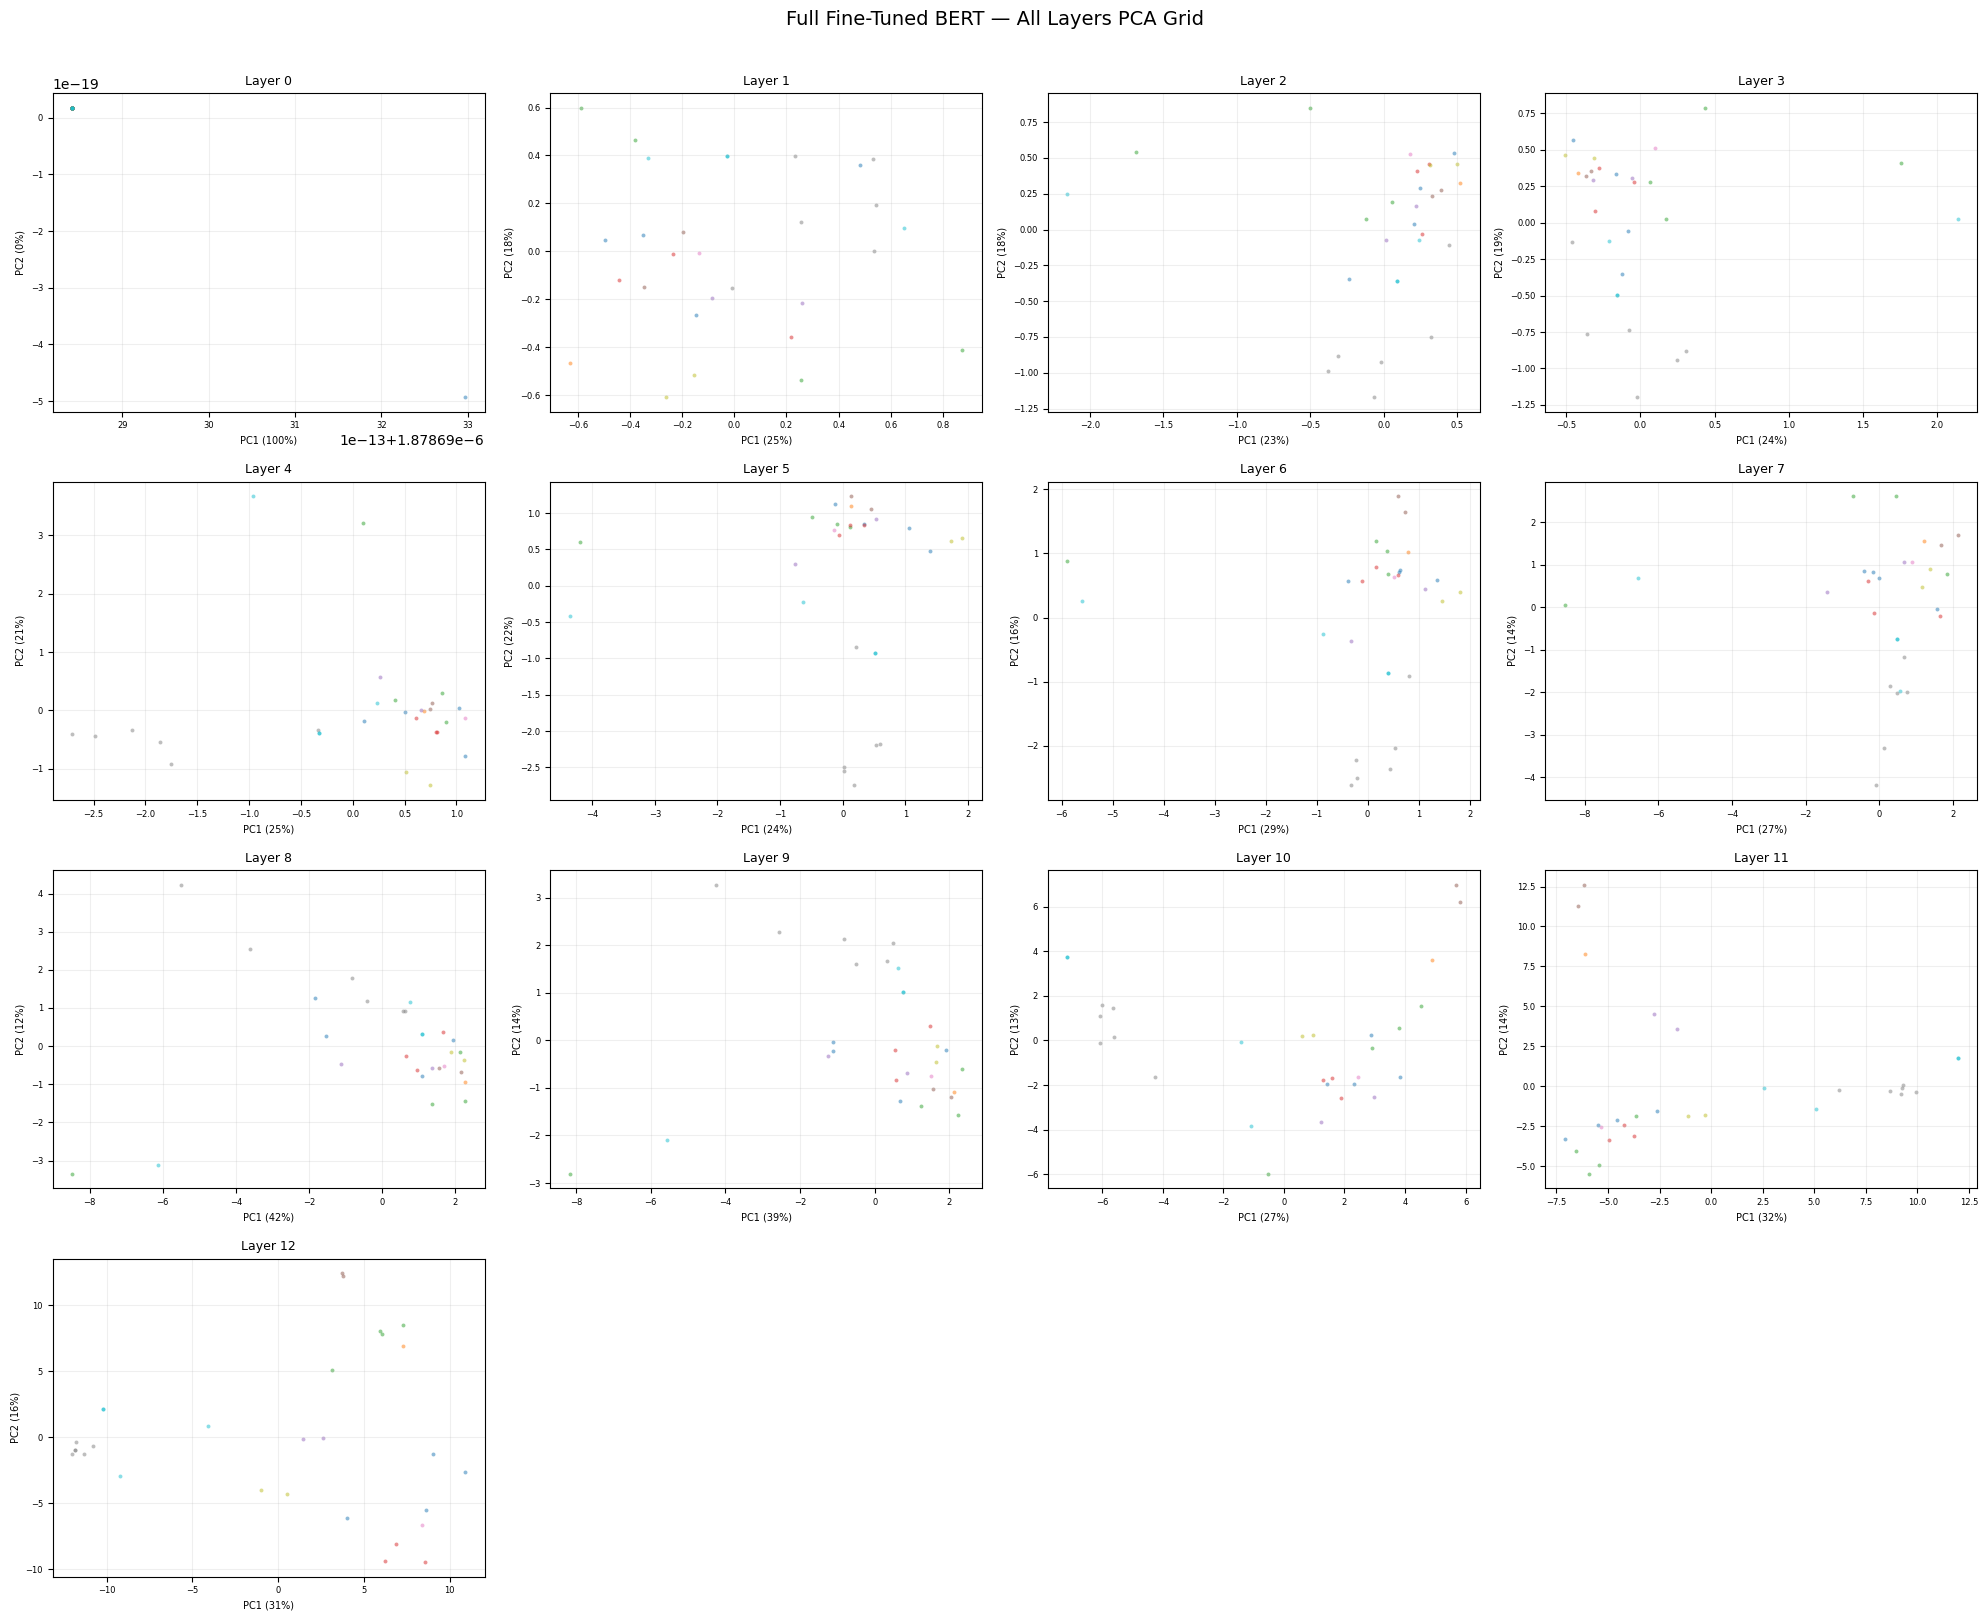

In [33]:
# =========================================
# Plot full fine-tuned BERT layer-wise PCA grid
# =========================================

finetuned_grid_file = os.path.join(
    OUTPUT_DIR,
    f"finetuned_all_layers_{POOLING}_grid.png"
)

plot_all_layers_grid(
    layer_vectors=finetuned_layer_vectors,
    labels=y_labels,
    model_name="Full Fine-Tuned BERT",
    output_file=finetuned_grid_file,
    show_plot=True
)

<h2>Compute Layer-Wise Silhouette Score</h2>

In [34]:
def compute_layer_silhouette_scores(layer_vectors, labels):
    """Compute the silhouette score for each BERT layer."""
    scores = {}
    for layer_idx, vectors in layer_vectors.items():
        try:
            score = silhouette_score(vectors, labels, metric="euclidean")
        except Exception as error:
            print(f"Layer {layer_idx} failed:", error)
            score = np.nan
        scores[layer_idx] = score
    return scores

pretrained_silhouette_scores = compute_layer_silhouette_scores(pretrained_layer_vectors, y_labels)  # TODO completed
finetuned_silhouette_scores  = compute_layer_silhouette_scores(finetuned_layer_vectors,  y_labels)  # TODO completed

print("Pretrained BERT silhouette scores:")
print(pretrained_silhouette_scores)
print("Full fine-tuned BERT silhouette scores:")
print(finetuned_silhouette_scores)


Pretrained BERT silhouette scores:
{0: np.float32(0.0), 1: np.float32(-0.068786934), 2: np.float32(-0.01093936), 3: np.float32(-0.026964717), 4: np.float32(0.020075532), 5: np.float32(-0.0036928758), 6: np.float32(-0.12423961), 7: np.float32(-0.1267122), 8: np.float32(-0.14735925), 9: np.float32(-0.12269003), 10: np.float32(-0.09727356), 11: np.float32(-0.052997272), 12: np.float32(-0.03658008)}
Full fine-tuned BERT silhouette scores:
{0: np.float32(0.0), 1: np.float32(-0.07148776), 2: np.float32(-0.010470344), 3: np.float32(-0.0014002033), 4: np.float32(0.08529716), 5: np.float32(0.07820251), 6: np.float32(0.010933982), 7: np.float32(-0.027042622), 8: np.float32(-0.11715141), 9: np.float32(-0.0573304), 10: np.float32(0.22468151), 11: np.float32(0.2833408), 12: np.float32(0.37801012)}


<h2>Plot Layer-Wise Silhouette Scores</h2>

In [35]:
def plot_layerwise_silhouette_scores(pretrained_scores, finetuned_scores,
                                      output_file=None, show_plot=True):
    layers = sorted(pretrained_scores.keys())                          # TODO completed
    pretrained_values = [pretrained_scores[layer] for layer in layers] # TODO completed
    finetuned_values  = [finetuned_scores[layer]  for layer in layers] # TODO completed

    plt.figure(figsize=(10, 6))
    plt.plot(layers, pretrained_values, marker="o", linewidth=2, label="Pretrained BERT")
    plt.plot(layers, finetuned_values,  marker="o", linewidth=2, label="Full Fine-Tuned BERT")
    plt.xlabel("Layer")
    plt.ylabel("Silhouette Score")
    plt.title("Layer-wise Class Separability")
    plt.xticks(layers)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, dpi=200, bbox_inches="tight")
        print("Saved:", output_file)
    if show_plot:
        plt.show()
    else:
        plt.close()


Saved: layerwise_bert_visualizations/layerwise_silhouette_cls.png


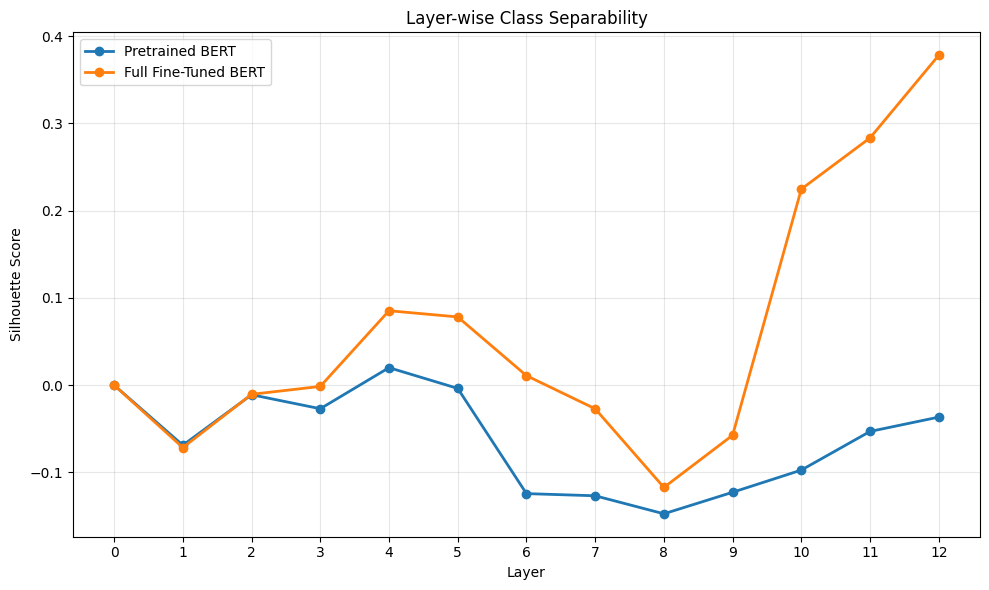

In [36]:
# =========================================
# Save and display the layer-wise silhouette plot
# =========================================

silhouette_plot_file = os.path.join(
    OUTPUT_DIR,
    f"layerwise_silhouette_{POOLING}.png"
)

plot_layerwise_silhouette_scores(
    pretrained_scores=pretrained_silhouette_scores,
    finetuned_scores=finetuned_silhouette_scores,
    output_file=silhouette_plot_file,
    show_plot=True
)